# 07: Final Report And Artifacts

This notebook packages **Off-Policy Evaluation of Recommendation Systems** into report-ready outputs.

The earlier notebooks did the technical work:

- Notebook 1: Open Bandit EDA
- Notebook 2: behavior policy and propensity diagnostics
- Notebook 3: IPS and SNIPS
- Notebook 4: doubly robust OPE
- Notebook 5: policy comparison and sensitivity
- Notebook 6: contextual policy learning

This final notebook does not introduce a new estimator. Its job is to turn the completed analysis into clean tables, figures, final recommendations, limitations, and technical-summary writing.


<!-- dataset-experiment-context -->
## Dataset and Experiment Context

This project uses the Open Bandit Dataset from a fashion e-commerce recommendation setting. Each row is a logged recommendation event with context features, the item action chosen by the behavior policy, a binary click reward, and the behavior-policy propensity for the chosen action.

The main analysis uses the `random/men` campaign because randomized logging gives broad action support and known propensities. Open Bandit also contains adaptive Bernoulli Thompson Sampling logs, but random logging is the cleanest starting point for off-policy evaluation.

The offline experiment asks which candidate recommendation policy deserves online validation. IPS, SNIPS, direct method, doubly robust estimates, effective sample size, clipping sensitivity, and reward-model diagnostics are treated as launch-readiness evidence for later online testing.

**Role of this notebook.** This notebook assembles final figures, tables, and text artifacts for a curated project page.

<!-- mathematical-setup -->

## Mathematical Setup

The final OPE report summarizes policy values, uncertainty, and support diagnostics. For each policy \(\pi_k\), the report keeps three quantities together:

$$
\left(\widehat V(\pi_k),\; \widehat{\operatorname{SE}}\{\widehat V(\pi_k)\},\; \operatorname{ESS}(\pi_k)\right).
$$

The decision comparison against a baseline is

$$
\widehat\Delta_k=\widehat V(\pi_k)-\widehat V(\pi_0).
$$

A good off-policy report explains whether the logged data contain enough behavior-policy support for the largest estimates to be taken seriously.


### Final Lab Goal

A analysis project should end with an artifact that a hiring manager or interviewer can understand quickly.

This notebook answers:

- What problem did the project solve?
- Which dataset and causal setup were used?
- Which estimators were implemented?
- Which recommendation policy is the best offline candidate for online testing?
- How stable is that recommendation?
- What limitations remain?

The final recommendation is intentionally cautious. Offline OPE can prioritize a policy for A/B testing, but it cannot prove production lift by itself.


#### Setup

This cell imports plotting and data libraries, sets display options, and defines a small helper for saving figures.

The notebook reads already-generated tables from `notebooks/projects/project_2_off_policy_evaluation/writeup/tables/`. That keeps the final report fast and reproducible without retraining models.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 140)
pd.set_option("display.float_format", "{:.6f}".format)

sns.set_theme(style="whitegrid", context="notebook")


This cell prepares the notebook environment for the final OPE report. There is no estimator output yet; the main value is that the imports, display settings, and plotting defaults are ready for the OPE diagnostics that follow.


#### Locate Project And Writeup Folders

This cell finds the repository root and creates the final report folders.

All final off-policy evaluation artifacts are written inside `notebooks/projects/project_2_off_policy_evaluation/writeup/` so they stay colocated with the notebooks. Figures go into `figures/`, tables go into `tables/`, and markdown snippets go into the writeup root.


In [2]:
TABLE_RELATIVE_PATH = Path("notebooks/projects/project_2_off_policy_evaluation/writeup/tables/main_lgbm_ope_estimates.csv")
PROJECT_ROOT = next(
    path
    for path in [Path.cwd(), *Path.cwd().parents]
    if (path / TABLE_RELATIVE_PATH).exists()
)

WRITEUP_DIR = PROJECT_ROOT / "notebooks/projects/project_2_off_policy_evaluation/writeup"
FIGURE_DIR = WRITEUP_DIR / "figures"
TABLE_DIR = WRITEUP_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

pd.Series(
    {
        "project_root": PROJECT_ROOT,
        "writeup_dir": WRITEUP_DIR,
        "figure_dir": FIGURE_DIR,
        "table_dir": TABLE_DIR,
    }
).to_frame("value")


,value
project_root,/home/apex/Documents/portfolio
writeup_dir,/home/apex/Documents/portfolio/notebooks/proje...
figure_dir,/home/apex/Documents/portfolio/notebooks/proje...
table_dir,/home/apex/Documents/portfolio/notebooks/proje...


The printed paths are a reproducibility checkpoint. Once the notebook can find the cached data and writeup folders, the rest of the analysis can run without manual path edits.


#### Load Final Analysis Tables

This cell loads the tables produced by Notebooks 5 and 6.

These tables contain the main OPE estimates, sensitivity checks, policy risk diagnostics, and contextual policy results. The final report notebook treats them as the source of truth for packaging.


In [3]:
# Load final analysis tables.
def load_table(name):
    """
    Load a saved project summary table by name.
    
    Idea
    ----
    The final artifact notebook uses this helper to read tables generated by earlier OPE notebooks without hard-coding repeated file paths.
    
    Parameters
    ----------
    name : object
        Artifact name or feature name to clean.
    
    Returns
    -------
    pandas.DataFrame
        Loaded CSV table from the project writeup directory.
    """
    path = TABLE_DIR / name
    if not path.exists():
        raise FileNotFoundError(f"Missing required table: {path}")
    return pd.read_csv(path)

main_lgbm = load_table("main_lgbm_ope_estimates.csv")
policy_risk = load_table("policy_risk_table.csv")
clipping_stability = load_table("clipping_stability.csv")
reward_model_rank = load_table("reward_model_rank_stability.csv")
split_rank = load_table("split_rank_stability.csv")
contextual_estimates = load_table("contextual_policy_estimates.csv")
contextual_audit = load_table("contextual_policy_audit.csv")
contextual_weights = load_table("contextual_weight_diagnostics.csv")
contextual_clipping = load_table("contextual_clipping_stability.csv")
contextual_decision = load_table("contextual_policy_decision_table.csv")

loaded_tables = pd.DataFrame(
    {
        "table": [
            "main_lgbm",
            "policy_risk",
            "clipping_stability",
            "reward_model_rank",
            "split_rank",
            "contextual_estimates",
            "contextual_audit",
            "contextual_weights",
            "contextual_clipping",
            "contextual_decision",
        ],
        "rows": [
            len(main_lgbm),
            len(policy_risk),
            len(clipping_stability),
            len(reward_model_rank),
            len(split_rank),
            len(contextual_estimates),
            len(contextual_audit),
            len(contextual_weights),
            len(contextual_clipping),
            len(contextual_decision),
        ],
    }
)

loaded_tables


,table,rows
0,main_lgbm,16
1,policy_risk,4
2,clipping_stability,12
3,reward_model_rank,4
4,split_rank,4
5,contextual_estimates,24
6,contextual_audit,6
7,contextual_weights,6
8,contextual_clipping,6
9,contextual_decision,6


The loaded table shape and preview confirm that the expected cached data is available. This check matters because all later OPE estimates depend on using the correct logged actions, rewards, contexts, and behavior propensities.


### Project Method Timeline

This table summarizes the technical arc of the project.

It is useful in a final report because it shows that the work moved from data validation to estimators, then to sensitivity checks and contextual policy learning. That progression matters for a analysis record: it demonstrates both causal inference fundamentals and recommendation-system judgment.


In [4]:
# Prepare project method timeline.
method_timeline = pd.DataFrame(
    [
        {
            "stage": "Dataset understanding",
            "notebook": "01_open_bandit_eda.ipynb",
            "purpose": "Verify actions, rewards, contexts, and logged propensities.",
        },
        {
            "stage": "Behavior-policy diagnostics",
            "notebook": "02_behavior_policy_and_propensities.ipynb",
            "purpose": "Check positivity, action support, propensity distributions, and IPS weight risk.",
        },
        {
            "stage": "Classical OPE",
            "notebook": "03_ips_and_snips.ipynb",
            "purpose": "Estimate fixed policy values with IPS and SNIPS.",
        },
        {
            "stage": "Doubly robust OPE",
            "notebook": "04_doubly_robust_ope.ipynb",
            "purpose": "Train reward models and combine direct method with residual correction.",
        },
        {
            "stage": "Sensitivity analysis",
            "notebook": "05_policy_comparison_and_sensitivity.ipynb",
            "purpose": "Stress-test conclusions across clipping, reward models, and time splits.",
        },
        {
            "stage": "Advanced contextual policy learning",
            "notebook": "06_contextual_policy_learning.ipynb",
            "purpose": "Learn context-aware policies from reward-model scores and evaluate them with DR OPE.",
        },
        {
            "stage": "Final packaging",
            "notebook": "07_final_report_and_artifacts.ipynb",
            "purpose": "Create final figures, tables, recommendations, and project text.",
        },
    ]
)

method_timeline


,stage,notebook,purpose
0,Dataset understanding,01_open_bandit_eda.ipynb,"Verify actions, rewards, contexts, and logged ..."
1,Behavior-policy diagnostics,02_behavior_policy_and_propensities.ipynb,"Check positivity, action support, propensity d..."
2,Classical OPE,03_ips_and_snips.ipynb,Estimate fixed policy values with IPS and SNIPS.
3,Doubly robust OPE,04_doubly_robust_ope.ipynb,Train reward models and combine direct method ...
4,Sensitivity analysis,05_policy_comparison_and_sensitivity.ipynb,"Stress-test conclusions across clipping, rewar..."
5,Advanced contextual policy learning,06_contextual_policy_learning.ipynb,Learn context-aware policies from reward-model...
6,Final packaging,07_final_report_and_artifacts.ipynb,"Create final figures, tables, recommendations,..."


The timeline organizes the project story from raw logs to final recommendation. This helps a reviewer understand how each notebook contributes to the final OPE decision. This keeps the analysis auditable: a reader can trace the final claim back to the exact table, figure, or markdown artifact that produced it.


### Final Fixed-Policy OPE Table

This table focuses on the strongest fixed-policy results from Notebook 5.

The fixed-policy recommendation is useful as a conservative baseline. These policies have clearer support than aggressive learned policies because they do not personalize by context. The table uses LightGBM doubly robust estimates and includes sensitivity diagnostics.


In [5]:
# Prepare final fixed-policy OPE table.
fixed_policy_final = policy_risk.copy()
fixed_policy_final["policy_type"] = "fixed"
fixed_policy_final["recommendation_role"] = np.where(
    fixed_policy_final["policy"] == "ctr_weighted",
    "stable fixed-policy candidate",
    "fixed-policy benchmark",
)
fixed_policy_final = fixed_policy_final[
    [
        "policy_type",
        "policy",
        "recommendation_role",
        "estimate",
        "ci_95_lower",
        "ci_95_upper",
        "lift_pp",
        "relative_lift_pct",
        "ess_share",
        "max_weight",
        "avg_rank_across_splits",
        "dr_estimate_range_across_splits",
        "decision_score",
    ]
].sort_values("estimate", ascending=False)

fixed_policy_final


,policy_type,policy,recommendation_role,estimate,ci_95_lower,ci_95_upper,lift_pp,relative_lift_pct,ess_share,max_weight,avg_rank_across_splits,dr_estimate_range_across_splits,decision_score
3,fixed,epsilon_greedy_top_ctr,fixed-policy benchmark,0.006622,0.004035,0.009209,0.164171,32.966042,0.040290,29.050000,2.000000,0.004269,-3.658854
2,fixed,ctr_weighted,stable fixed-policy candidate,0.005282,0.004759,0.005805,0.030172,6.058681,0.790628,2.740842,1.666667,0.001205,-0.660579
0,fixed,uniform,fixed-policy benchmark,0.005034,0.004592,0.005476,0.005411,1.086540,1.000000,1.000000,3.333333,0.001374,-0.927922
1,fixed,exposure_popularity,fixed-policy benchmark,0.005020,0.004578,0.005462,0.003997,0.802658,0.996399,1.132200,3.000000,0.001285,-0.859223


The final table distills the offline evidence into a small set of decision-relevant rows. This is the version most useful for a project report or stakeholder-facing summary.


### Figure 1: Fixed-Policy Value Estimates

This figure compares IPS, SNIPS, and DR estimates for the fixed policies.

The figure is designed for the final report. DR is the preferred estimator, but IPS and SNIPS remain useful benchmarks because they show how much the answer depends on modeling assumptions.


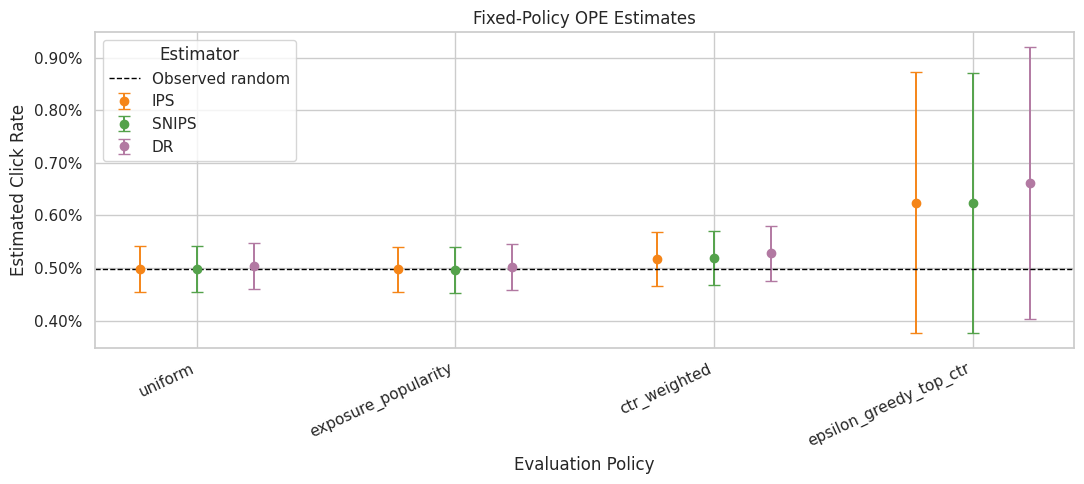

PosixPath('/home/apex/Documents/portfolio/notebooks/projects/project_2_off_policy_evaluation/writeup/figures/01_fixed_policy_ope_estimates.png')

In [6]:
# Create Figure 1 showing fixed-policy value estimates.
fixed_plot = main_lgbm.query("estimator in ['IPS', 'SNIPS', 'DR']").copy()
fixed_plot["lower_error"] = fixed_plot["estimate"] - fixed_plot["ci_95_lower"]
fixed_plot["upper_error"] = fixed_plot["ci_95_upper"] - fixed_plot["estimate"]

policy_order = fixed_plot["policy"].drop_duplicates().tolist()
estimator_order = ["IPS", "SNIPS", "DR"]
offsets = {"IPS": -0.22, "SNIPS": 0.0, "DR": 0.22}
colors = {"IPS": "#F58518", "SNIPS": "#54A24B", "DR": "#B279A2"}

fig, ax = plt.subplots(figsize=(11, 5))
for estimator in estimator_order:
    subset = fixed_plot[fixed_plot["estimator"] == estimator]
    for _, row in subset.iterrows():
        x_base = policy_order.index(row["policy"])
        x = x_base + offsets[estimator]
        ax.errorbar(
            x=x,
            y=row["estimate"],
            yerr=[[row["lower_error"]], [row["upper_error"]]],
            fmt="o",
            color=colors[estimator],
            ecolor=colors[estimator],
            capsize=4,
            linewidth=1.4,
            markersize=6,
            label=estimator if row["policy"] == subset["policy"].iloc[0] else None,
        )

baseline = main_lgbm["eval_observed_click_rate"].iloc[0]
ax.axhline(baseline, color="black", linestyle="--", linewidth=1, label="Observed random")
ax.set_xticks(range(len(policy_order)))
ax.set_xticklabels(policy_order, rotation=25, ha="right")
ax.set_title("Fixed-Policy OPE Estimates")
ax.set_xlabel("Evaluation Policy")
ax.set_ylabel("Estimated Click Rate")
ax.yaxis.set_major_formatter(lambda y, _: f"{y:.2%}")
ax.legend(title="Estimator")
plt.tight_layout()

fixed_estimate_figure = FIGURE_DIR / "01_fixed_policy_ope_estimates.png"
fig.savefig(fixed_estimate_figure, dpi=180, bbox_inches="tight")
plt.show()

fixed_estimate_figure


The estimate plot compares policies on the same offline value scale. Error bars and estimator differences are just as important as the ranking, because high-variance estimates should not drive product decisions alone.


### Final Contextual-Policy Decision Table

This table summarizes the advanced contextual policies from Notebook 6.

The important interpretation is the tradeoff between value and support. Greedy policies may have higher point estimates, but low ESS and clipping sensitivity make them risky. Conservative contextual mixtures can be more realistic candidates for online testing.


In [7]:
# Prepare final contextual-policy decision table.
contextual_final = contextual_decision.copy()
contextual_final["policy_type"] = np.where(
    contextual_final["policy"].str.startswith("lgbm"), "contextual", "fixed benchmark"
)
contextual_final["recommendation_role"] = np.select(
    [
        contextual_final["policy"] == "lgbm_conservative_mix",
        contextual_final["policy"] == "fixed_ctr_weighted",
        contextual_final["risk_flag"].isin(["low ESS", "clip sensitive"]),
    ],
    [
        "primary contextual A/B-test candidate",
        "stable fixed-policy fallback",
        "high-value but fragile offline estimate",
    ],
    default="benchmark",
)
contextual_final = contextual_final[
    [
        "policy_type",
        "policy",
        "recommendation_role",
        "estimate",
        "ci_95_lower",
        "ci_95_upper",
        "lift_pp",
        "relative_lift_pct",
        "ess_share",
        "max_weight",
        "p99_weight",
        "dr_estimate_range",
        "support_adjusted_lift_pp",
        "risk_flag",
    ]
]

contextual_final


,policy_type,policy,recommendation_role,estimate,ci_95_lower,ci_95_upper,lift_pp,relative_lift_pct,ess_share,max_weight,p99_weight,dr_estimate_range,support_adjusted_lift_pp,risk_flag
0,contextual,lgbm_greedy,high-value but fragile offline estimate,0.007513,0.003857,0.011170,0.253344,50.872251,0.029100,34.000000,34.000000,0.027226,0.043217,low ESS
1,contextual,lgbm_epsilon_greedy,high-value but fragile offline estimate,0.007142,0.004016,0.010267,0.216160,43.405703,0.039955,29.050000,29.050000,0.022579,0.043208,low ESS
2,contextual,lgbm_softmax,high-value but fragile offline estimate,0.006001,0.003518,0.008484,0.102106,20.503156,0.168632,34.000000,5.113957,0.018609,0.041930,clip sensitive
3,contextual,lgbm_conservative_mix,primary contextual A/B-test candidate,0.005324,0.004434,0.006215,0.034450,6.917631,0.694032,10.900000,2.234187,0.003497,0.028700,clip sensitive
4,fixed benchmark,fixed_ctr_weighted,stable fixed-policy fallback,0.005281,0.004757,0.005806,0.030119,6.048007,0.790628,2.740842,2.740842,0.000000,0.026781,reasonable support
5,fixed benchmark,uniform,benchmark,0.005035,0.004592,0.005477,0.005454,1.095263,1.000000,1.000000,1.000000,0.000000,0.005454,reasonable support


The final table distills the offline evidence into a small set of decision-relevant rows. This is the version most useful for a project report or stakeholder-facing summary.


### Figure 2: Contextual Policy Value and Risk

This figure shows the final DR estimates for fixed and contextual policies.

Colors identify risk status. The plot makes the core message visible: the most aggressive contextual policies can have high estimated value, but the safer recommendation usually comes from balancing lift against support diagnostics.


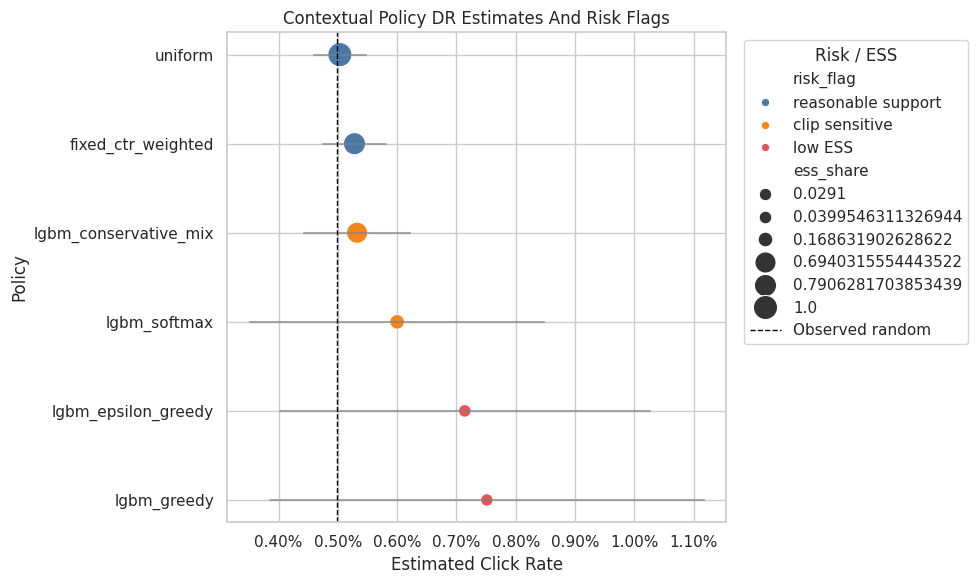

PosixPath('/home/apex/Documents/portfolio/notebooks/projects/project_2_off_policy_evaluation/writeup/figures/02_contextual_policy_value_and_risk.png')

In [8]:
# Create Figure 2 showing contextual policy value and risk.
contextual_plot = contextual_final.copy().sort_values("estimate", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
palette = {
    "reasonable support": "#4C78A8",
    "clip sensitive": "#F58518",
    "low ESS": "#E45756",
}
sns.scatterplot(
    data=contextual_plot,
    x="estimate",
    y="policy",
    hue="risk_flag",
    size="ess_share",
    sizes=(80, 300),
    palette=palette,
    ax=ax,
)
for _, row in contextual_plot.iterrows():
    ax.plot([row["ci_95_lower"], row["ci_95_upper"]], [row["policy"], row["policy"]], color="gray", alpha=0.65)
ax.axvline(baseline, color="black", linestyle="--", linewidth=1, label="Observed random")
ax.set_title("Contextual Policy DR Estimates And Risk Flags")
ax.set_xlabel("Estimated Click Rate")
ax.set_ylabel("Policy")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
ax.legend(title="Risk / ESS", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

contextual_value_figure = FIGURE_DIR / "02_contextual_policy_value_and_risk.png"
fig.savefig(contextual_value_figure, dpi=180, bbox_inches="tight")
plt.show()

contextual_value_figure


This figure turns the final OPE results into a visual artifact for the writeup. The plot should be read together with support and sensitivity tables, not as a standalone proof that a policy will win online.


### Figure 3: Lift versus Effective Sample Size

This figure plots estimated DR lift against effective sample size share.

This is one of the clearest final-report visuals because it shows the policy tradeoff directly. A policy in the upper-right is attractive: high lift and strong support. A policy in the upper-left may be promising but fragile.


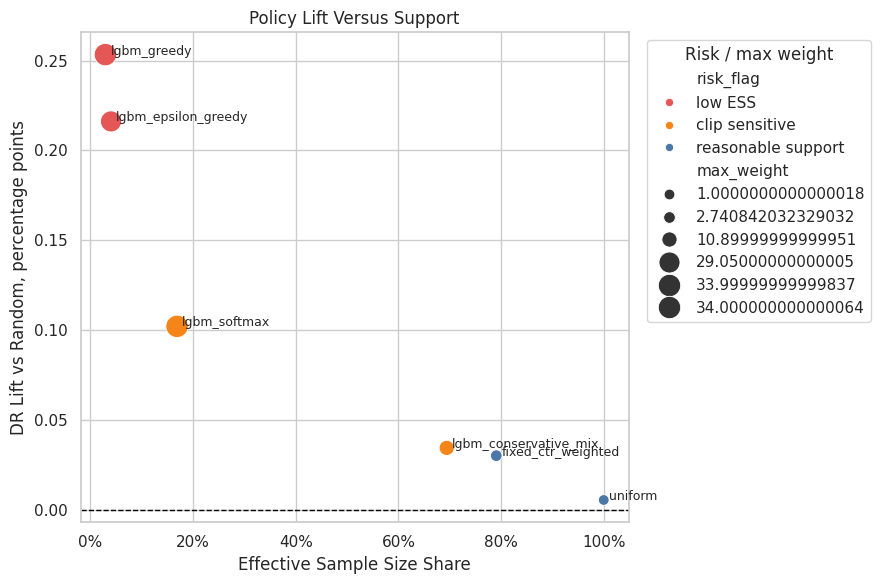

PosixPath('/home/apex/Documents/portfolio/notebooks/projects/project_2_off_policy_evaluation/writeup/figures/03_lift_vs_support.png')

In [9]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(
    data=contextual_final,
    x="ess_share",
    y="lift_pp",
    hue="risk_flag",
    size="max_weight",
    sizes=(60, 260),
    palette=palette,
    ax=ax,
)
for _, row in contextual_final.iterrows():
    ax.text(row["ess_share"] + 0.01, row["lift_pp"], row["policy"], fontsize=9)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set_title("Policy Lift Versus Support")
ax.set_xlabel("Effective Sample Size Share")
ax.set_ylabel("DR Lift vs Random, percentage points")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}")
ax.legend(title="Risk / max weight", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

support_lift_figure = FIGURE_DIR / "03_lift_vs_support.png"
fig.savefig(support_lift_figure, dpi=180, bbox_inches="tight")
plt.show()

support_lift_figure


Effective sample size turns weight concentration into an intuitive sample-size diagnostic. A low ESS means the estimator has less usable information than the raw row count suggests.


### Figure 4: Clipping Sensitivity

This figure summarizes DR clipping sensitivity for contextual policies.

A large clipping range means the estimate changes when high weights are capped. That is a warning sign that the policy value depends on a small number of high-weight rows.


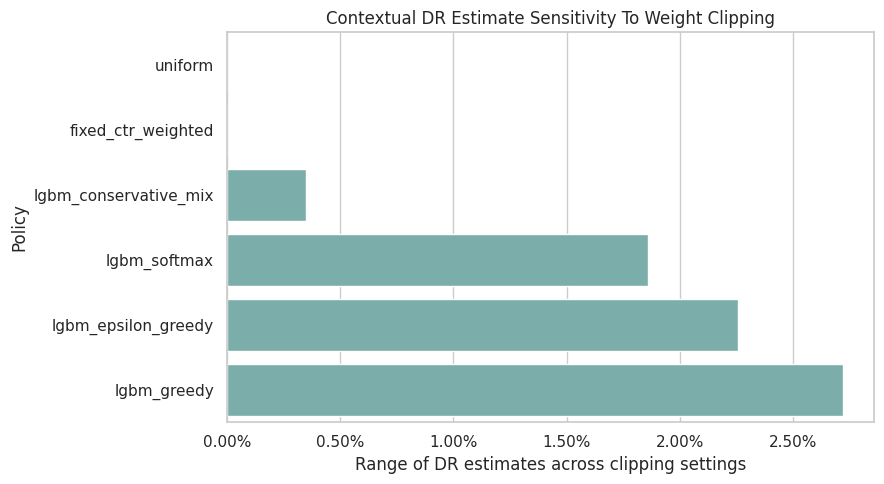

PosixPath('/home/apex/Documents/portfolio/notebooks/projects/project_2_off_policy_evaluation/writeup/figures/04_contextual_clipping_sensitivity.png')

In [10]:
clipping_plot = contextual_clipping.sort_values("dr_estimate_range", ascending=True).copy()

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=clipping_plot, x="dr_estimate_range", y="policy", color="#72B7B2", ax=ax)
ax.set_title("Contextual DR Estimate Sensitivity To Weight Clipping")
ax.set_xlabel("Range of DR estimates across clipping settings")
ax.set_ylabel("Policy")
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.2%}")
plt.tight_layout()

clipping_figure = FIGURE_DIR / "04_contextual_clipping_sensitivity.png"
fig.savefig(clipping_figure, dpi=180, bbox_inches="tight")
plt.show()

clipping_figure


The clipping sensitivity check shows how estimates change when extreme weights are capped. Stable estimates across clipping thresholds are more reassuring than estimates that depend strongly on a few high-weight rows.


#### Final Recommendation Table

This cell creates the final recommendation table.

The recommendation is deliberately split into two roles:

- a **primary contextual candidate** that uses personalization while preserving more support than a greedy policy
- a **stable fixed-policy fallback** that is simpler and has stronger support diagnostics

This framing shows product judgment alongside modeling discipline.


In [11]:
# Prepare final recommendation table.
primary_contextual = contextual_final.query("policy == 'lgbm_conservative_mix'").iloc[0]
stable_fixed = contextual_final.query("policy == 'fixed_ctr_weighted'").iloc[0]
aggressive_reference = contextual_final.query("policy == 'lgbm_greedy'").iloc[0]

final_recommendation = pd.DataFrame(
    [
        {
            "role": "primary A/B-test candidate",
            "policy": primary_contextual["policy"],
            "reason": "Context-aware policy with materially better support than greedy learned policies.",
            "estimated_click_rate": primary_contextual["estimate"],
            "lift_pp": primary_contextual["lift_pp"],
            "relative_lift_pct": primary_contextual["relative_lift_pct"],
            "ess_share": primary_contextual["ess_share"],
            "max_weight": primary_contextual["max_weight"],
            "risk_flag": primary_contextual["risk_flag"],
        },
        {
            "role": "stable fallback candidate",
            "policy": stable_fixed["policy"],
            "reason": "Simpler fixed policy with reasonable support and low clipping sensitivity.",
            "estimated_click_rate": stable_fixed["estimate"],
            "lift_pp": stable_fixed["lift_pp"],
            "relative_lift_pct": stable_fixed["relative_lift_pct"],
            "ess_share": stable_fixed["ess_share"],
            "max_weight": stable_fixed["max_weight"],
            "risk_flag": stable_fixed["risk_flag"],
        },
        {
            "role": "not recommended as first rollout",
            "policy": aggressive_reference["policy"],
            "reason": "High estimated value but very low ESS and high clipping sensitivity.",
            "estimated_click_rate": aggressive_reference["estimate"],
            "lift_pp": aggressive_reference["lift_pp"],
            "relative_lift_pct": aggressive_reference["relative_lift_pct"],
            "ess_share": aggressive_reference["ess_share"],
            "max_weight": aggressive_reference["max_weight"],
            "risk_flag": aggressive_reference["risk_flag"],
        },
    ]
)

final_recommendation_path = TABLE_DIR / "final_recommendation.csv"
final_recommendation.to_csv(final_recommendation_path, index=False)

final_recommendation


,role,policy,reason,estimated_click_rate,lift_pp,relative_lift_pct,ess_share,max_weight,risk_flag
0,primary A/B-test candidate,lgbm_conservative_mix,Context-aware policy with materially better su...,0.005324,0.034450,6.917631,0.694032,10.900000,clip sensitive
1,stable fallback candidate,fixed_ctr_weighted,Simpler fixed policy with reasonable support a...,0.005281,0.030119,6.048007,0.790628,2.740842,reasonable support
2,not recommended as first rollout,lgbm_greedy,High estimated value but very low ESS and high...,0.007513,0.253344,50.872251,0.029100,34.000000,low ESS


The final table distills the offline evidence into a small set of decision-relevant rows. This is the version most useful for a project report or stakeholder-facing summary.


### Limitations Table

This table lists the main limitations that should appear in the final report.

The limitations are part of the value of the project. In causal recommendation work, being explicit about support, logging propensities, short-term outcomes, and online validation makes the analysis more credible.


In [12]:
# Prepare limitations table.
limitations = pd.DataFrame(
    [
        {
            "limitation": "Offline OPE is not an online experiment",
            "impact": "The estimates prioritize A/B-test candidates but do not prove production lift.",
            "mitigation": "Run an online experiment with guardrail metrics before launch.",
        },
        {
            "limitation": "Support and positivity constraints",
            "impact": "Aggressive learned policies can have low ESS and high weight sensitivity.",
            "mitigation": "Use conservative mixtures and monitor ESS, max weights, and clipping sensitivity.",
        },
        {
            "limitation": "Reward is short-term click",
            "impact": "Click lift may not equal long-term satisfaction, retention, or content discovery quality.",
            "mitigation": "Add downstream engagement and retention guardrails in online testing.",
        },
        {
            "limitation": "Reward-model dependence",
            "impact": "Direct method and DR estimates depend partly on model quality and calibration.",
            "mitigation": "Compare reward models, calibration, and residual correction diagnostics.",
        },
        {
            "limitation": "Single Open Bandit campaign slice",
            "impact": "The project focuses on the `random/men` slice for clarity and support.",
            "mitigation": "Extend to other campaigns or BTS logs as a robustness check.",
        },
    ]
)

limitations_path = TABLE_DIR / "limitations.csv"
limitations.to_csv(limitations_path, index=False)

limitations


,limitation,impact,mitigation
0,Offline OPE is not an online experiment,The estimates prioritize A/B-test candidates b...,Run an online experiment with guardrail metric...
1,Support and positivity constraints,Aggressive learned policies can have low ESS a...,"Use conservative mixtures and monitor ESS, max..."
2,Reward is short-term click,Click lift may not equal long-term satisfactio...,Add downstream engagement and retention guardr...
3,Reward-model dependence,Direct method and DR estimates depend partly o...,"Compare reward models, calibration, and residu..."
4,Single Open Bandit campaign slice,The project focuses on the `random/men` slice ...,Extend to other campaigns or BTS logs as a rob...


The limitations table states the boundary of the offline analysis. This is a strength of the project because it shows judgment about support, unobserved confounding, logging assumptions, and the need for online validation.


#### Final Project Summary Text

This cell writes a concise project summary that can be reused in a README, project page, or review notes.

The wording is intentionally careful. It describes the policy as an offline A/B-test candidate under the available evidence.


In [13]:
summary_text = f"""# Final Summary: Off-Policy Evaluation Of Recommendation Systems

## Problem
This project evaluates recommendation policies offline using logged bandit data. The business question asks which recommendation policy is most credible to advance to an online A/B test.

## Dataset
The analysis uses the Open Bandit Dataset, focusing on the `random/men` campaign because it contains logged actions, click rewards, context features, and known behavior-policy propensities. The random behavior policy provides broad support, which is important for reliable off-policy evaluation.

## Methods
The project implements IPS, self-normalized IPS, direct method, doubly robust OPE, weight diagnostics, reward-model diagnostics, clipping sensitivity, reward-model sensitivity, split sensitivity, and contextual policy learning with LightGBM reward scores.

## Final Recommendation
The primary offline A/B-test candidate is `{primary_contextual['policy']}`. Its estimated DR click rate is {primary_contextual['estimate']:.4%}, with estimated lift of {primary_contextual['lift_pp']:.3f} percentage points versus the observed random-policy baseline. Because this policy is still marked `{primary_contextual['risk_flag']}`, the safer fallback is `{stable_fixed['policy']}`, which has stronger support diagnostics and estimated lift of {stable_fixed['lift_pp']:.3f} percentage points.

## Interpretation
The project recommends a prioritized online experiment based on offline OPE evidence. Test a conservative contextual policy or stable fixed policy against the current/random baseline while tracking click quality, longer-term engagement, and user experience guardrails.
""".strip()

summary_path = WRITEUP_DIR / "final_project_summary.md"
summary_path.write_text(summary_text + "\n")

print(summary_text)


# Final Summary: Off-Policy Evaluation Of Recommendation Systems

## Problem
This project evaluates recommendation policies offline using logged bandit data. The business question asks which recommendation policy is most credible to advance to an online A/B test.

## Dataset
The analysis uses the Open Bandit Dataset, focusing on the `random/men` campaign because it contains logged actions, click rewards, context features, and known behavior-policy propensities. The random behavior policy provides broad support, which is important for reliable off-policy evaluation.

## Methods
The project implements IPS, self-normalized IPS, direct method, doubly robust OPE, weight diagnostics, reward-model diagnostics, clipping sensitivity, reward-model sensitivity, split sensitivity, and contextual policy learning with LightGBM reward scores.

## Final Recommendation
The primary offline A/B-test candidate is `lgbm_conservative_mix`. Its estimated DR click rate is 0.5324%, with estimated lift of 0.034

This cell saves reusable outputs for downstream notebooks or the final report. Persisting these artifacts makes the project modular and prevents later notebooks from repeating expensive or fragile setup work.


#### Technical Summary Bullets

This cell writes technical-summary bullets for data science roles.

The bullets are specific enough to show technical substance and product relevance. They mention OPE, recommendation systems, propensities, doubly robust estimation, and contextual policy learning.


In [14]:
technical_summary_bullets = f"""# Technical Summary Bullets

- Built an off-policy evaluation framework for recommendation systems using Open Bandit logs, estimating counterfactual policy value with IPS, self-normalized IPS, direct method, and doubly robust estimators from logged propensities.
- Trained LightGBM reward models to learn context-aware recommendation policies, then evaluated greedy, epsilon-greedy, softmax, and conservative mixed policies with ESS, clipping sensitivity, and residual-correction diagnostics.
- Produced an A/B-test recommendation framework that balanced estimated click lift with support risk, identifying `{primary_contextual['policy']}` as a contextual candidate and `{stable_fixed['policy']}` as a stable fallback policy.
""".strip()

technical_summary_path = WRITEUP_DIR / "technical_summary_bullets.md"
technical_summary_path.write_text(technical_summary_bullets + "\n")

print(technical_summary_bullets)


# Technical Summary Bullets

- Built an off-policy evaluation framework for recommendation systems using Open Bandit logs, estimating counterfactual policy value with IPS, self-normalized IPS, direct method, and doubly robust estimators from logged propensities.
- Trained LightGBM reward models to learn context-aware recommendation policies, then evaluated greedy, epsilon-greedy, softmax, and conservative mixed policies with ESS, clipping sensitivity, and residual-correction diagnostics.
- Produced an A/B-test recommendation framework that balanced estimated click lift with support risk, identifying `lgbm_conservative_mix` as a contextual candidate and `fixed_ctr_weighted` as a stable fallback policy.


This cell saves reusable outputs for downstream notebooks or the final report. Persisting these artifacts makes the project modular and prevents later notebooks from repeating expensive or fragile setup work.


#### Final Artifact Index

This final cell lists the files generated for the off-policy evaluation writeup.

The artifact index is useful because the project now has several notebooks and many generated files. This table tells you exactly which figures, tables, and markdown snippets are ready for the README or project page.


In [15]:
artifact_paths = sorted(
    [path for path in WRITEUP_DIR.rglob("*") if path.is_file()]
)
artifact_index = pd.DataFrame(
    {
        "path": [str(path.relative_to(PROJECT_ROOT)) for path in artifact_paths],
        "size_kb": [path.stat().st_size / 1024 for path in artifact_paths],
    }
)

artifact_index_path = TABLE_DIR / "artifact_index.csv"
artifact_index.to_csv(artifact_index_path, index=False)

artifact_index


,path,size_kb
0,notebooks/projects/project_2_off_policy_evalua...,111.525391
1,notebooks/projects/project_2_off_policy_evalua...,144.845703
2,notebooks/projects/project_2_off_policy_evalua...,142.990234
3,notebooks/projects/project_2_off_policy_evalua...,70.702148
4,notebooks/projects/project_2_off_policy_evalua...,1.499023
5,notebooks/projects/project_2_off_policy_evalua...,0.692383
6,notebooks/projects/project_2_off_policy_evalua...,1.876953
7,notebooks/projects/project_2_off_policy_evalua...,1.283203
8,notebooks/projects/project_2_off_policy_evalua...,0.702148
9,notebooks/projects/project_2_off_policy_evalua...,0.830078


This cell saves reusable outputs for downstream notebooks or the final report. Persisting these artifacts makes the project modular and prevents later notebooks from repeating expensive or fragile setup work.


## Takeaways and Next Step

The off-policy evaluation work is now packaged as a complete analysis project.

The final outputs include:

- method timeline
- fixed-policy OPE comparison
- contextual-policy decision table
- lift versus support figure
- clipping sensitivity figure
- final recommendation table
- limitations table
- project summary markdown
- technical summary bullets
- artifact index

The project has a complete technical arc: it starts from logged bandit data, validates propensities and support, implements classical and doubly robust OPE, stress-tests policy conclusions, learns contextual policies, and ends with a cautious A/B-test recommendation.
